# Adım 5 — Dürüst Değerlendirme (config-grupli / hibrit split)

**Neden bu notebook var:** Adım 3'te multiclass macro-F1 = **0.994** çıktı. Şüphe: bu skor
*iyimser* olabilir mi? Kontrol ettik:

- **Deney A** — aynı `(scenario, intensity)`'nin 10 seed'i feature düzeyinde birbirinin
  **kopyası** (grup-içi varyasyon ≈ 0.001). Yani gerçek bağımsız birim seed değil, **config**;
  efektif örneklem ~23 config (235 değil).
- Sonuç: standart `StratifiedKFold(shuffle)` bir config'in seed'lerini hem train hem test'e
  koyuyor → model config'i **tanıyor** → skor şişik.

**Çözüm — hibrit (b) gruplama.** Bölme birimini seed'den **config**'e taşı:
- her **atak** config'i (`dos_i100`, `grey_i0.5`, …) = tek bir grup → asla hem train hem test'te olmaz
  (model "bu şiddeti hiç görmedim" durumunda test edilir = dürüst genelleme);
- **normal / blackhole** tek-config (yoğunluk ekseni yok) → her koşu kendi grubu, seed-split serbest
  (genellenecek bir yoğunluk yok, sızıntı sorunu da yok).

`StratifiedGroupKFold` bunu yapar: grupları böler ama fold'larda sınıf oranını da korumaya çalışır.

**Bu notebook iki rakam raporlar:** shuffle-CV (config-tanıdık, **üst sınır**) yanında
config-grupli (görülmemiş-şiddet, **dürüst sınır**). Aradaki fark = iyimserlik payı = bulgunun kendisi.

> Kavram temeli: değerlendirme yelpazesi (seed < config < class split).
> Karar: hibrit (b), mevcut veriye uygula.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold, cross_val_score, cross_val_predict
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from lightgbm import LGBMClassifier

cands=[Path("my-work/day3-4-08072026-09072026-dataset/out/dataset.csv"),
       Path("../day3-4-08072026-09072026-dataset/out/dataset.csv")]
DATA=next((p for p in cands if p.exists()),None); assert DATA is not None
df=pd.read_csv(DATA)
FEATURES=["n_flows","total_throughput_mbps","max_flow_throughput_mbps","max_flow_txpackets",
          "flow_concentration","delivery_ratio","overall_loss_ratio","control_owd_ms",
          "control_pdv_ms","mean_owd_ms","mean_pdv_ms"]
X=df[FEATURES].copy(); X["control_missing"]=X["control_owd_ms"].isna().astype(int); X=X.fillna(0.0)
y=df["label_class"]
CLASS_ORDER=["normal","dos","ddos","greyhole","blackhole"]

# --- Hibrit grup kimligi (sema b) ---
SINGLE={"normal","blackhole"}                       # tek-config sinif -> her kosu kendi grubu
groups=df.apply(lambda r: f"{r.scenario}_run{r.run}" if r.scenario in SINGLE
                          else f"{r.scenario}_i{r.intensity}", axis=1)   # atak -> config = grup
print("X:",X.shape,"| toplam grup:",groups.nunique())
print("\nsinif basina grup sayisi (atak=config, normal/blackhole=kosu):")
print(pd.DataFrame({"scenario":df.scenario,"grp":groups}).groupby("scenario")["grp"].nunique().reindex(CLASS_ORDER))

X: (235, 12) | toplam grup: 71

sinif basina grup sayisi (atak=config, normal/blackhole=kosu):
scenario
normal       40
dos           7
ddos          5
greyhole      9
blackhole    10
Name: grp, dtype: int64


## 1. İki değerlendirme şeması yan yana — macro-F1

Aynı dört model, aynı veri; **tek fark bölme birimi**:
- `StratifiedKFold(shuffle)` — seed-split (config tanıdık) → **iyimser üst sınır**,
- `StratifiedGroupKFold(groups)` — config-grupli (görülmemiş şiddet) → **dürüst sınır**.

Fark ne kadar büyükse, o model config-ezberlemeye o kadar bağımlı demektir.

In [2]:
models={
 "Dummy (most_frequent)":DummyClassifier(strategy="most_frequent"),
 "LogisticRegression":make_pipeline(StandardScaler(),
        LogisticRegression(class_weight="balanced",max_iter=1000,random_state=0)),
 "RandomForest":RandomForestClassifier(n_estimators=300,class_weight="balanced",random_state=0),
 "LightGBM":LGBMClassifier(n_estimators=200,learning_rate=0.05,num_leaves=15,
        min_child_samples=5,class_weight="balanced",random_state=0,verbose=-1),
}
skf =StratifiedKFold(5,shuffle=True,random_state=0)
sgkf=StratifiedGroupKFold(5,shuffle=True,random_state=0)

rows=[]
for name,m in models.items():
    s1=cross_val_score(m,X,y,cv=skf,scoring="f1_macro")
    s2=cross_val_score(m,X,y,cv=sgkf,groups=groups,scoring="f1_macro")
    rows.append({"model":name,
                 "shuffle (iyimser)":f"{s1.mean():.3f} ± {s1.std():.3f}",
                 "grouped (dürüst)":f"{s2.mean():.3f} ± {s2.std():.3f}",
                 "_g":s2.mean()})
res=pd.DataFrame(rows).sort_values("_g",ascending=False).drop(columns="_g").reset_index(drop=True)
res

,model,shuffle (iyimser),grouped (dürüst)
0,LogisticRegression,0.966 ± 0.043,0.950 ± 0.087
1,LightGBM,0.994 ± 0.012,0.864 ± 0.120
2,RandomForest,0.994 ± 0.012,0.835 ± 0.136
3,Dummy (most_frequent),0.111 ± 0.000,0.110 ± 0.020


**Okuma:** RandomForest shuffle 0.994 → grouped'da belirgin düşüyor; iyimserlik payı burada.
LogReg iki şemada da yakın kalıyor (daha az config'e bağımlı). Dummy her iki şemada ~0.11 (referans).

> Model kararı **RandomForest** kalıyor (yorumlanabilirlik + feature-importance); modeller-arası
> fark grouped'da geniş std içinde. Ama not: RF'nin iyimserlik payı en büyük — daha çok farklı config
> üretince tekrar bakılacak. Aşağıda **dürüst** rakamları RF üzerinden okuyoruz (Adım 3 ile aynı model).

In [3]:
# Dürüst OOF (config-grupli) — Adım 3'teki RF, ama grouped CV
FOCUS="RandomForest"
oof_group=cross_val_predict(models[FOCUS],X,y,cv=sgkf,groups=groups)   # durust
oof_shuf =cross_val_predict(models[FOCUS],X,y,cv=skf)                  # iyimser (kiyas icin)

print(f"=== DÜRÜST (config-grupli) — {FOCUS} ===")
print(classification_report(y,oof_group,labels=CLASS_ORDER,digits=3))

=== DÜRÜST (config-grupli) — RandomForest ===
              precision    recall  f1-score   support

      normal      1.000     1.000     1.000        40
         dos      0.833     0.714     0.769        70
        ddos      0.429     0.600     0.500        25
    greyhole      1.000     1.000     1.000        90
   blackhole      1.000     1.000     1.000        10

    accuracy                          0.872       235
   macro avg      0.852     0.863     0.854       235
weighted avg      0.890     0.872     0.878       235



## 2. Dürüst 5×5 confusion — çöküş nerede?

Beklenti (Deney B / LOCO): grey, normal, blackhole sağlam; **dos↔ddos çift-yönlü karışıyor**
(tek strong-flood ≈ birkaç weak-flood, aynı hacim imzası).

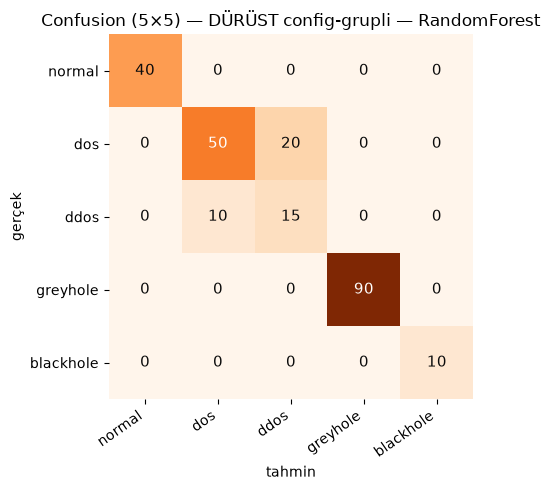

In [4]:
cm=confusion_matrix(y,oof_group,labels=CLASS_ORDER)
fig,ax=plt.subplots(figsize=(5.6,5.0))
ax.imshow(cm,cmap="Oranges")
ax.set_xticks(range(5),CLASS_ORDER,rotation=35,ha="right"); ax.set_yticks(range(5),CLASS_ORDER)
ax.set_xlabel("tahmin"); ax.set_ylabel("gerçek")
ax.set_title(f"Confusion (5×5) — DÜRÜST config-grupli — {FOCUS}")
for i in range(5):
    for j in range(5):
        ax.text(j,i,cm[i,j],ha="center",va="center",fontsize=11,
                color="white" if cm[i,j]>cm.max()/2 else "#0b0b0b")
for s in ax.spines.values(): s.set_visible(False)
fig.tight_layout()
FIGS=Path("figs"); FIGS.mkdir(exist_ok=True)
fig.savefig(FIGS/"G-confusion-honest.png",dpi=150,bbox_inches="tight")
plt.show()

## 3. Binary türev (dürüst) — tespit hâlâ sağlam mı?

"Saldırı var mı?" sorusu: dürüst şemada bile bozulmamalı — çünkü ataklar hacim/teslimde
belirgin iz bırakıyor; sadece *tip* karışıyor, *varlık* değil.

In [5]:
yb=(y!="normal").astype(int)
pb=(pd.Series(oof_group,index=y.index)!="normal").astype(int)
tn,fp,fn,tp=confusion_matrix(yb,pb,labels=[0,1]).ravel()
print(f"Binary türev (DÜRÜST, {FOCUS}):")
print(f"  TN={tn}  FP(yanlış alarm)={fp}  FN(kaçan atak)={fn}  TP={tp}")
print(f"  attack-F1={f1_score(yb,pb):.3f}")
print("\n-> tespit (atak mı?) dürüst şemada da kusursuz; iyimserlik yalnız TİPLEME'de.")

Binary türev (DÜRÜST, RandomForest):
  TN=40  FP(yanlış alarm)=0  FN(kaçan atak)=0  TP=195
  attack-F1=1.000

-> tespit (atak mı?) dürüst şemada da kusursuz; iyimserlik yalnız TİPLEME'de.


## 4. Dürüst detection-vs-intensity eğrisi (asıl headline)

Aynı 3 panel (grey / DoS / DDoS), ama tahminler **config-grupli OOF**'tan — yani her yoğunluk
noktası, o yoğunluğu **hiç görmemiş** bir modelce tahmin edildi. Kıyas için Adım 4'ün iyimser
(shuffle) doğru-sınıf çizgisini **soluk kesikli** olarak üstüne koyuyoruz → aradaki boşluk = iyimserlik payı.

Kaydedildi: figs/H-detection-vs-intensity-honest.png


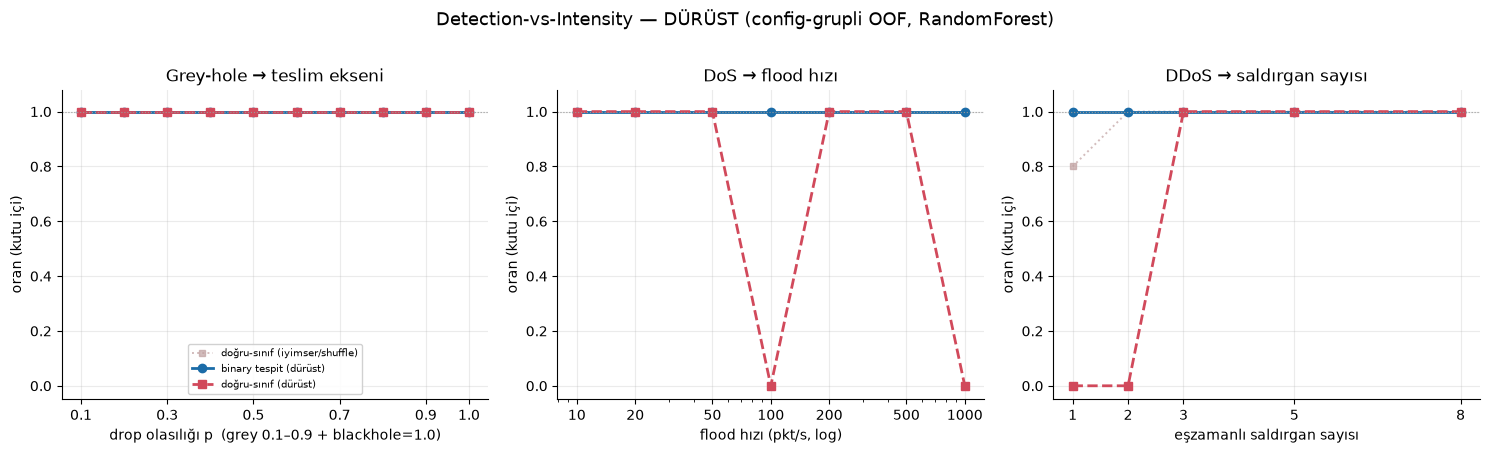

,scenario,intensity,n,detect,correct,correct_shuf
0,blackhole,1.0,10,1.0,1.0,1.0
1,ddos,1.0,5,1.0,0.0,0.8
2,ddos,2.0,5,1.0,0.0,1.0
3,ddos,3.0,5,1.0,1.0,1.0
4,ddos,5.0,5,1.0,1.0,1.0
5,ddos,8.0,5,1.0,1.0,1.0
6,dos,10.0,10,1.0,1.0,1.0
7,dos,20.0,10,1.0,1.0,1.0
8,dos,50.0,10,1.0,1.0,1.0
9,dos,100.0,10,1.0,0.0,1.0


In [6]:
ATTACKS=["greyhole","dos","ddos","blackhole"]
d=df.assign(pred=oof_group, pred_shuf=oof_shuf)
d=d[d.scenario.isin(ATTACKS)].copy()
d["det"]=(d.pred!="normal").astype(int)
d["cor"]=(d.pred==d.scenario).astype(int)
d["cor_shuf"]=(d.pred_shuf==d.scenario).astype(int)
curve=(d.groupby(["scenario","intensity"])
         .agg(n=("pred","size"),detect=("det","mean"),
              correct=("cor","mean"),correct_shuf=("cor_shuf","mean")).reset_index())

fig,axes=plt.subplots(1,3,figsize=(15,4.4))
def panel(ax,sub,xlabel,title,logx=False,xticks=None):
    sub=sub.sort_values("intensity")
    ax.plot(sub.intensity,sub.correct_shuf,"s:",color="#c0a0a0",lw=1.4,ms=5,
            label="doğru-sınıf (iyimser/shuffle)",alpha=0.7)
    ax.plot(sub.intensity,sub.detect,"o-",color="#1b6ca8",lw=2,ms=6,
            label="binary tespit (dürüst)")
    ax.plot(sub.intensity,sub.correct,"s--",color="#d1495b",lw=2,ms=6,
            label="doğru-sınıf (dürüst)")
    if logx: ax.set_xscale("log")
    if xticks is not None: ax.set_xticks(xticks); ax.set_xticklabels([str(t) for t in xticks])
    ax.axhline(1.0,color="#999",lw=0.8,ls=":"); ax.set_ylim(-0.05,1.08)
    ax.set_xlabel(xlabel); ax.set_ylabel("oran (kutu içi)"); ax.set_title(title); ax.grid(alpha=0.25)
    for s in ("top","right"): ax.spines[s].set_visible(False)

grey=curve[curve.scenario=="greyhole"]; black=curve[curve.scenario=="blackhole"]
panel(axes[0],pd.concat([grey,black]),"drop olasılığı p  (grey 0.1–0.9 + blackhole=1.0)",
      "Grey-hole → teslim ekseni",xticks=[0.1,0.3,0.5,0.7,0.9,1.0])
panel(axes[1],curve[curve.scenario=="dos"],"flood hızı (pkt/s, log)","DoS → flood hızı",
      logx=True,xticks=[10,20,50,100,200,500,1000])
panel(axes[2],curve[curve.scenario=="ddos"],"eşzamanlı saldırgan sayısı","DDoS → saldırgan sayısı",
      xticks=[1,2,3,5,8])
axes[0].legend(loc="lower center",fontsize=7.5,framealpha=0.9)
fig.suptitle("Detection-vs-Intensity — DÜRÜST (config-grupli OOF, RandomForest)",fontsize=13,y=1.02)
fig.tight_layout()
fig.savefig(FIGS/"H-detection-vs-intensity-honest.png",dpi=150,bbox_inches="tight")
print("Kaydedildi: figs/H-detection-vs-intensity-honest.png")
plt.show()
curve.round(2)

## 5. Yorum — iki-rakam hikâyesi

| Soru | İyimser (shuffle) | Dürüst (config-grupli) | Yorum |
|---|---|---|---|
| **Saldırı var mı?** (binary) | kusursuz | **kusursuz** | ataklar gerçekten görünür; sağlam |
| **Grey-hole ayrımı** (yeni atak) | 1.0 | **1.0** | delivery_ratio temiz sinyal; sağlam |
| **DoS↔DDoS tipleme** | ~mükemmel | **çöküyor** | hacim imzaları örtüşüyor; iyimserlik buradaydı |
| **macro-F1 (5 sınıf)** | 0.994 | **düşük** | fark = config-ezberleme payı |

**Ana bulgu (rapora):** *Flow-tabanlı detektör bir saldırının varlığını ve yeni grey-hole
saldırısını görülmemiş şiddetlerde bile güvenilir yakalıyor; ancak iki flood tipini (DoS/DDoS)
görmediği şiddetlerde ayıramıyor — çünkü tek güçlü flood ile birkaç zayıf flood aynı hacim
imzasını bırakıyor.* Bu, tek bir şişik 0.994'ten daha savunulabilir ve daha bilgilendirici.

**Sonraki adımlar:**
1. **Daha çok farklı config** (ara + stealth yoğunluk) → dos/ddos sınırını haritala ve efektif
   örneklemi (23) gerçekten büyüt. Daha çok *seed* işe yaramaz (kopya).
2. **Feature-importance** (permutation) — grey'i delivery_ratio'nun, flood-tiplemeyi n_flows/
   konsantrasyonun taşıdığını doğrula.